In [1]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"GPU Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

CUDA Available: True
GPU Device: Tesla T4


In [3]:
!pip install -q datasets transformers accelerate

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import requests
import io

train_url = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv"
test_url = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv"

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

train_df.columns = ['text', 'label']
test_df.columns = ['text', 'label']

print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"\nDataset columns: {train_df.columns.tolist()}")
print(f"\nFirst 3 samples:")
print(train_df.head(3))
print(f"\nDataset info:")
print(train_df.info())

Train samples: 10003
Test samples: 3080

Dataset columns: ['text', 'label']

First 3 samples:
                                                text         label
0                     I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived ...  card_arrival
2  I have been waiting over a week. Is the card s...  card_arrival

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10003 non-null  object
 1   label   10003 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB
None


Number of unique intents: 77

Class distribution in training set:
label
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64

Class distribution statistics:
Min samples per class: 35
Max samples per class: 187
Mean samples per class: 129.91
Std samples per class: 32.94


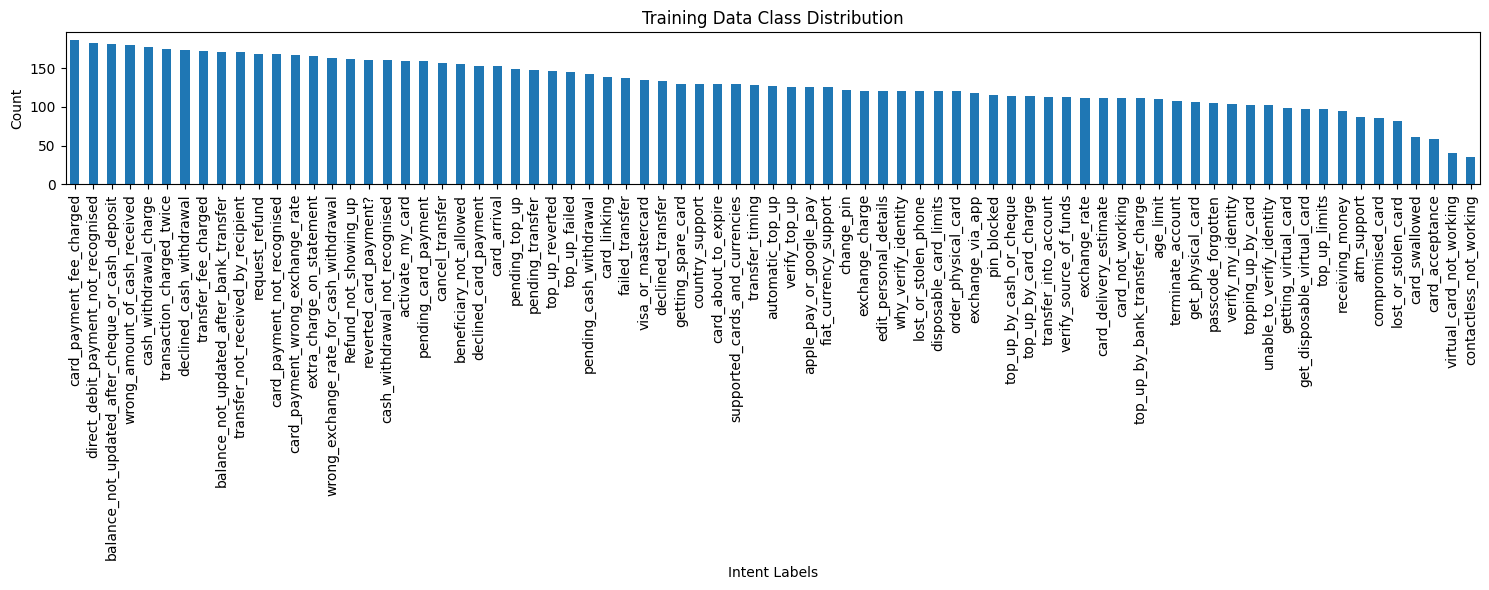

In [11]:
train_label_counts = train_df['label'].value_counts()
test_label_counts = test_df['label'].value_counts()

print(f"Number of unique intents: {train_df['label'].nunique()}")
print(f"\nClass distribution in training set:")
print(train_label_counts)
print(f"\nClass distribution statistics:")
print(f"Min samples per class: {train_label_counts.min()}")
print(f"Max samples per class: {train_label_counts.max()}")
print(f"Mean samples per class: {train_label_counts.mean():.2f}")
print(f"Std samples per class: {train_label_counts.std():.2f}")

plt.figure(figsize=(15, 6))
train_label_counts.plot(kind='bar')
plt.title('Training Data Class Distribution')
plt.xlabel('Intent Labels')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Text length statistics:
count    10003.000000
mean        59.473758
std         40.867901
min         13.000000
25%         36.000000
50%         47.000000
75%         64.000000
max        433.000000
Name: text_length, dtype: float64

Word count statistics:
count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: word_count, dtype: float64

Sample queries by length:

Shortest query (13 chars):
Can I top up?

Longest query (433 chars):
Hearing back from us regarding your important verification results may take 10 minutes to one hour time.  If verification results do fail, double-check to make sure all of your images are clear --  make sure your photos have no glare or blurring. Note: These photos need to be readable as well.  You also need to be 18 years of age or older.  You must be a resident of Switzerland or the European Economic Area to open a new account.


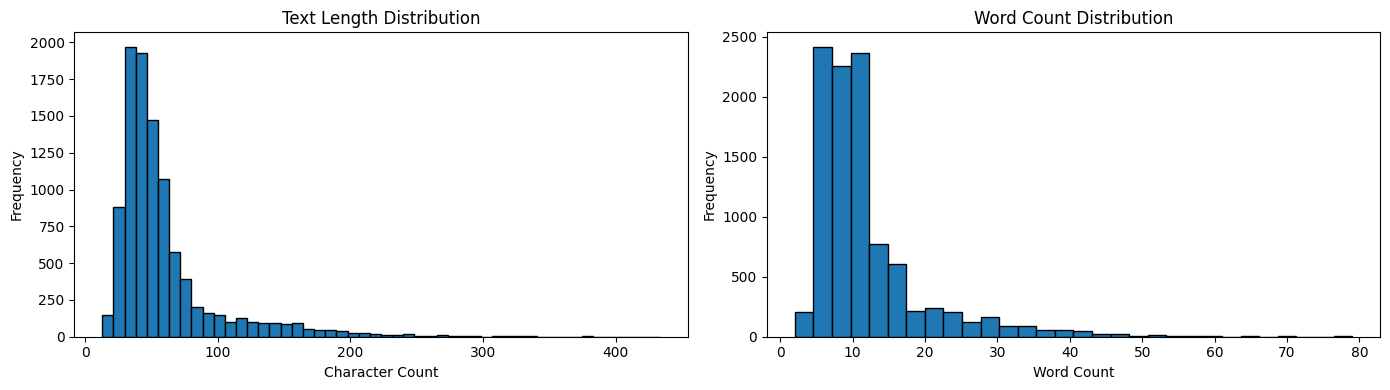

In [12]:
train_df['text_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].str.split().str.len()

print("Text length statistics:")
print(train_df['text_length'].describe())
print(f"\nWord count statistics:")
print(train_df['word_count'].describe())
print(f"\nSample queries by length:")
print(f"\nShortest query ({train_df['text_length'].min()} chars):")
print(train_df.loc[train_df['text_length'].idxmin(), 'text'])
print(f"\nLongest query ({train_df['text_length'].max()} chars):")
print(train_df.loc[train_df['text_length'].idxmax(), 'text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_df['text_length'], bins=50, edgecolor='black')
axes[0].set_title('Text Length Distribution')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[1].hist(train_df['word_count'], bins=30, edgecolor='black')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

train_df = train_df.drop(['text_length', 'word_count'], axis=1)

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
test_df['label_encoded'] = label_encoder.transform(test_df['label'])

num_labels = len(label_encoder.classes_)
label_to_id = {label: idx for idx, label in enumerate(label_encoder.classes_)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

print(f"Total number of labels: {num_labels}")
print(f"\nFirst 10 label mappings:")
for i, (label, idx) in enumerate(list(label_to_id.items())[:10]):
    print(f"{idx}: {label}")

print(f"\nEncoded labels in train set:")
print(train_df[['text', 'label', 'label_encoded']].head(5))

Total number of labels: 77

First 10 label mappings:
0: Refund_not_showing_up
1: activate_my_card
2: age_limit
3: apple_pay_or_google_pay
4: atm_support
5: automatic_top_up
6: balance_not_updated_after_bank_transfer
7: balance_not_updated_after_cheque_or_cash_deposit
8: beneficiary_not_allowed
9: cancel_transfer

Encoded labels in train set:
                                                text         label  \
0                     I am still waiting on my card?  card_arrival   
1  What can I do if my card still hasn't arrived ...  card_arrival   
2  I have been waiting over a week. Is the card s...  card_arrival   
3  Can I track my card while it is in the process...  card_arrival   
4  How do I know if I will get my card, or if it ...  card_arrival   

   label_encoded  
0             12  
1             12  
2             12  
3             12  
4             12  


In [14]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_encoded']),
    y=train_df['label_encoded']
)

class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"Class weights computed for {len(class_weights)} classes")
print(f"\nSample class weights (first 10):")
for i in range(10):
    print(f"Class {i} ({id_to_label[i]}): {class_weights_dict[i]:.4f}")

print(f"\nWeight statistics:")
print(f"Min weight: {class_weights.min():.4f}")
print(f"Max weight: {class_weights.max():.4f}")
print(f"Mean weight: {class_weights.mean():.4f}")

class_weights_tensor = torch.tensor(list(class_weights_dict.values()), dtype=torch.float)

Class weights computed for 77 classes

Sample class weights (first 10):
Class 0 (Refund_not_showing_up): 0.8019
Class 1 (activate_my_card): 0.8170
Class 2 (age_limit): 1.1810
Class 3 (apple_pay_or_google_pay): 1.0310
Class 4 (atm_support): 1.4932
Class 5 (automatic_top_up): 1.0229
Class 6 (balance_not_updated_after_bank_transfer): 0.7597
Class 7 (balance_not_updated_after_cheque_or_cash_deposit): 0.7177
Class 8 (beneficiary_not_allowed): 0.8328
Class 9 (cancel_transfer): 0.8274

Weight statistics:
Min weight: 0.6947
Max weight: 3.7117
Mean weight: 1.1021


In [15]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(texts):
    return tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )

print("Tokenizing training data...")
train_encodings = tokenize_function(train_df['text'].tolist())
print("Tokenizing test data...")
test_encodings = tokenize_function(test_df['text'].tolist())

print(f"\nTokenization complete:")
print(f"Train input_ids shape: {train_encodings['input_ids'].shape}")
print(f"Test input_ids shape: {test_encodings['input_ids'].shape}")
print(f"\nSample tokenized output (first text):")
print(f"Original text: {train_df['text'].iloc[0]}")
print(f"Token IDs: {train_encodings['input_ids'][0][:20].tolist()}...")
print(f"Decoded tokens: {tokenizer.decode(train_encodings['input_ids'][0][:20])}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenizing training data...
Tokenizing test data...

Tokenization complete:
Train input_ids shape: torch.Size([10003, 128])
Test input_ids shape: torch.Size([3080, 128])

Sample tokenized output (first text):
Original text: I am still waiting on my card?
Token IDs: [101, 1045, 2572, 2145, 3403, 2006, 2026, 4003, 1029, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
Decoded tokens: [CLS] i am still waiting on my card? [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]


In [16]:
from torch.utils.data import Dataset

class IntentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IntentDataset(train_encodings, train_df['label_encoded'].values)
test_dataset = IntentDataset(test_encodings, test_df['label_encoded'].values)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"\nSample from train dataset:")
sample = train_dataset[0]
print(f"Keys: {sample.keys()}")
print(f"Input IDs shape: {sample['input_ids'].shape}")
print(f"Attention mask shape: {sample['attention_mask'].shape}")
print(f"Label: {sample['labels'].item()} ({id_to_label[sample['labels'].item()]})")

Train dataset size: 10003
Test dataset size: 3080

Sample from train dataset:
Keys: dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])
Input IDs shape: torch.Size([128])
Attention mask shape: torch.Size([128])
Label: 12 (card_arrival)


In [17]:
from transformers import BertForSequenceClassification
import torch.nn as nn

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels,
    problem_type="single_label_classification"
)

model.to('cuda' if torch.cuda.is_available() else 'cpu')

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model loaded: {model.__class__.__name__}")
print(f"Number of labels: {num_labels}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Device: {next(model.parameters()).device}")
print(f"\nModel architecture:")
print(model)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: BertForSequenceClassification
Number of labels: 77
Total parameters: 109,541,453
Trainable parameters: 109,541,453
Device: cuda:0

Model architecture:
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )


In [18]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("Metrics function defined successfully")
print("Metrics tracked: accuracy, f1, precision, recall")

Metrics function defined successfully
Metrics tracked: accuracy, f1, precision, recall


In [19]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=2,
    learning_rate=2e-5,
    fp16=True,
    report_to="none"
)

print("Training configuration:")
print(f"Epochs: {training_args.num_train_epochs}")
print(f"Train batch size: {training_args.per_device_train_batch_size}")
print(f"Eval batch size: {training_args.per_device_eval_batch_size}")
print(f"Learning rate: {training_args.learning_rate}")
print(f"Warmup steps: {training_args.warmup_steps}")
print(f"Weight decay: {training_args.weight_decay}")
print(f"FP16 training: {training_args.fp16}")
print(f"Evaluation strategy: {training_args.eval_strategy}")

Training configuration:
Epochs: 4
Train batch size: 16
Eval batch size: 32
Learning rate: 2e-05
Warmup steps: 500
Weight decay: 0.01
FP16 training: True
Evaluation strategy: IntervalStrategy.EPOCH


In [20]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Trainer initialized with weighted loss function")
print(f"Training samples: {len(train_dataset)}")
print(f"Evaluation samples: {len(test_dataset)}")
print(f"Steps per epoch: {len(train_dataset) // training_args.per_device_train_batch_size}")
print(f"Total training steps: {(len(train_dataset) // training_args.per_device_train_batch_size) * training_args.num_train_epochs}")

Trainer initialized with weighted loss function
Training samples: 10003
Evaluation samples: 3080
Steps per epoch: 625
Total training steps: 2500


In [22]:
print("Starting training...")
print("-" * 60)

train_result = trainer.train()

print("-" * 60)
print("Training completed!")
print(f"\nTraining metrics:")
print(f"Total training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"Training loss: {train_result.metrics['train_loss']:.4f}")
print(f"Samples per second: {train_result.metrics['train_samples_per_second']:.2f}")

Starting training...
------------------------------------------------------------


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,3.120800,2.593429,0.568182,0.516313,0.622130,0.568182
2,1.347100,1.075861,0.861039,0.858750,0.876056,0.861039
3,0.744300,0.613853,0.912013,0.911902,0.917286,0.912013
4,0.509400,0.510541,0.919156,0.919244,0.923958,0.919156


------------------------------------------------------------
Training completed!

Training metrics:
Total training time: 421.91 seconds
Training loss: 1.7727
Samples per second: 94.83


In [23]:
print("Evaluating model on test set...")
eval_results = trainer.evaluate()

print("\nFinal Evaluation Metrics:")
print(f"Accuracy: {eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)")
print(f"F1 Score: {eval_results['eval_f1']:.4f}")
print(f"Precision: {eval_results['eval_precision']:.4f}")
print(f"Recall: {eval_results['eval_recall']:.4f}")
print(f"Evaluation Loss: {eval_results['eval_loss']:.4f}")
print(f"Evaluation Runtime: {eval_results['eval_runtime']:.2f} seconds")
print(f"Samples per second: {eval_results['eval_samples_per_second']:.2f}")

Evaluating model on test set...



Final Evaluation Metrics:
Accuracy: 0.9192 (91.92%)
F1 Score: 0.9192
Precision: 0.9240
Recall: 0.9192
Evaluation Loss: 0.5105
Evaluation Runtime: 6.13 seconds
Samples per second: 502.48


In [27]:
from sklearn.metrics import confusion_matrix

predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)
y_true = test_df['label_encoded'].values

cm = confusion_matrix(y_true, y_pred)

print(f"Predictions generated for {len(y_pred)} samples")
print(f"Confusion matrix shape: {cm.shape}")
print(f"\nCorrectly classified: {(y_pred == y_true).sum()}")
print(f"Misclassified: {(y_pred != y_true).sum()}")
print(f"\nSample predictions:")
for i in range(5):
    print(f"True: {id_to_label[y_true[i]]}")
    print(f"Predicted: {id_to_label[y_pred[i]]}")
    print(f"Text: {test_df['text'].iloc[i]}")
    print("-" * 50)

Predictions generated for 3080 samples
Confusion matrix shape: (77, 77)

Correctly classified: 2831
Misclassified: 249

Sample predictions:
True: card_arrival
Predicted: lost_or_stolen_card
Text: How do I locate my card?
--------------------------------------------------
True: card_arrival
Predicted: card_arrival
Text: I still have not received my new card, I ordered over a week ago.
--------------------------------------------------
True: card_arrival
Predicted: card_arrival
Text: I ordered a card but it has not arrived. Help please!
--------------------------------------------------
True: card_arrival
Predicted: card_delivery_estimate
Text: Is there a way to know when my card will arrive?
--------------------------------------------------
True: card_arrival
Predicted: card_arrival
Text: My card has not arrived yet.
--------------------------------------------------


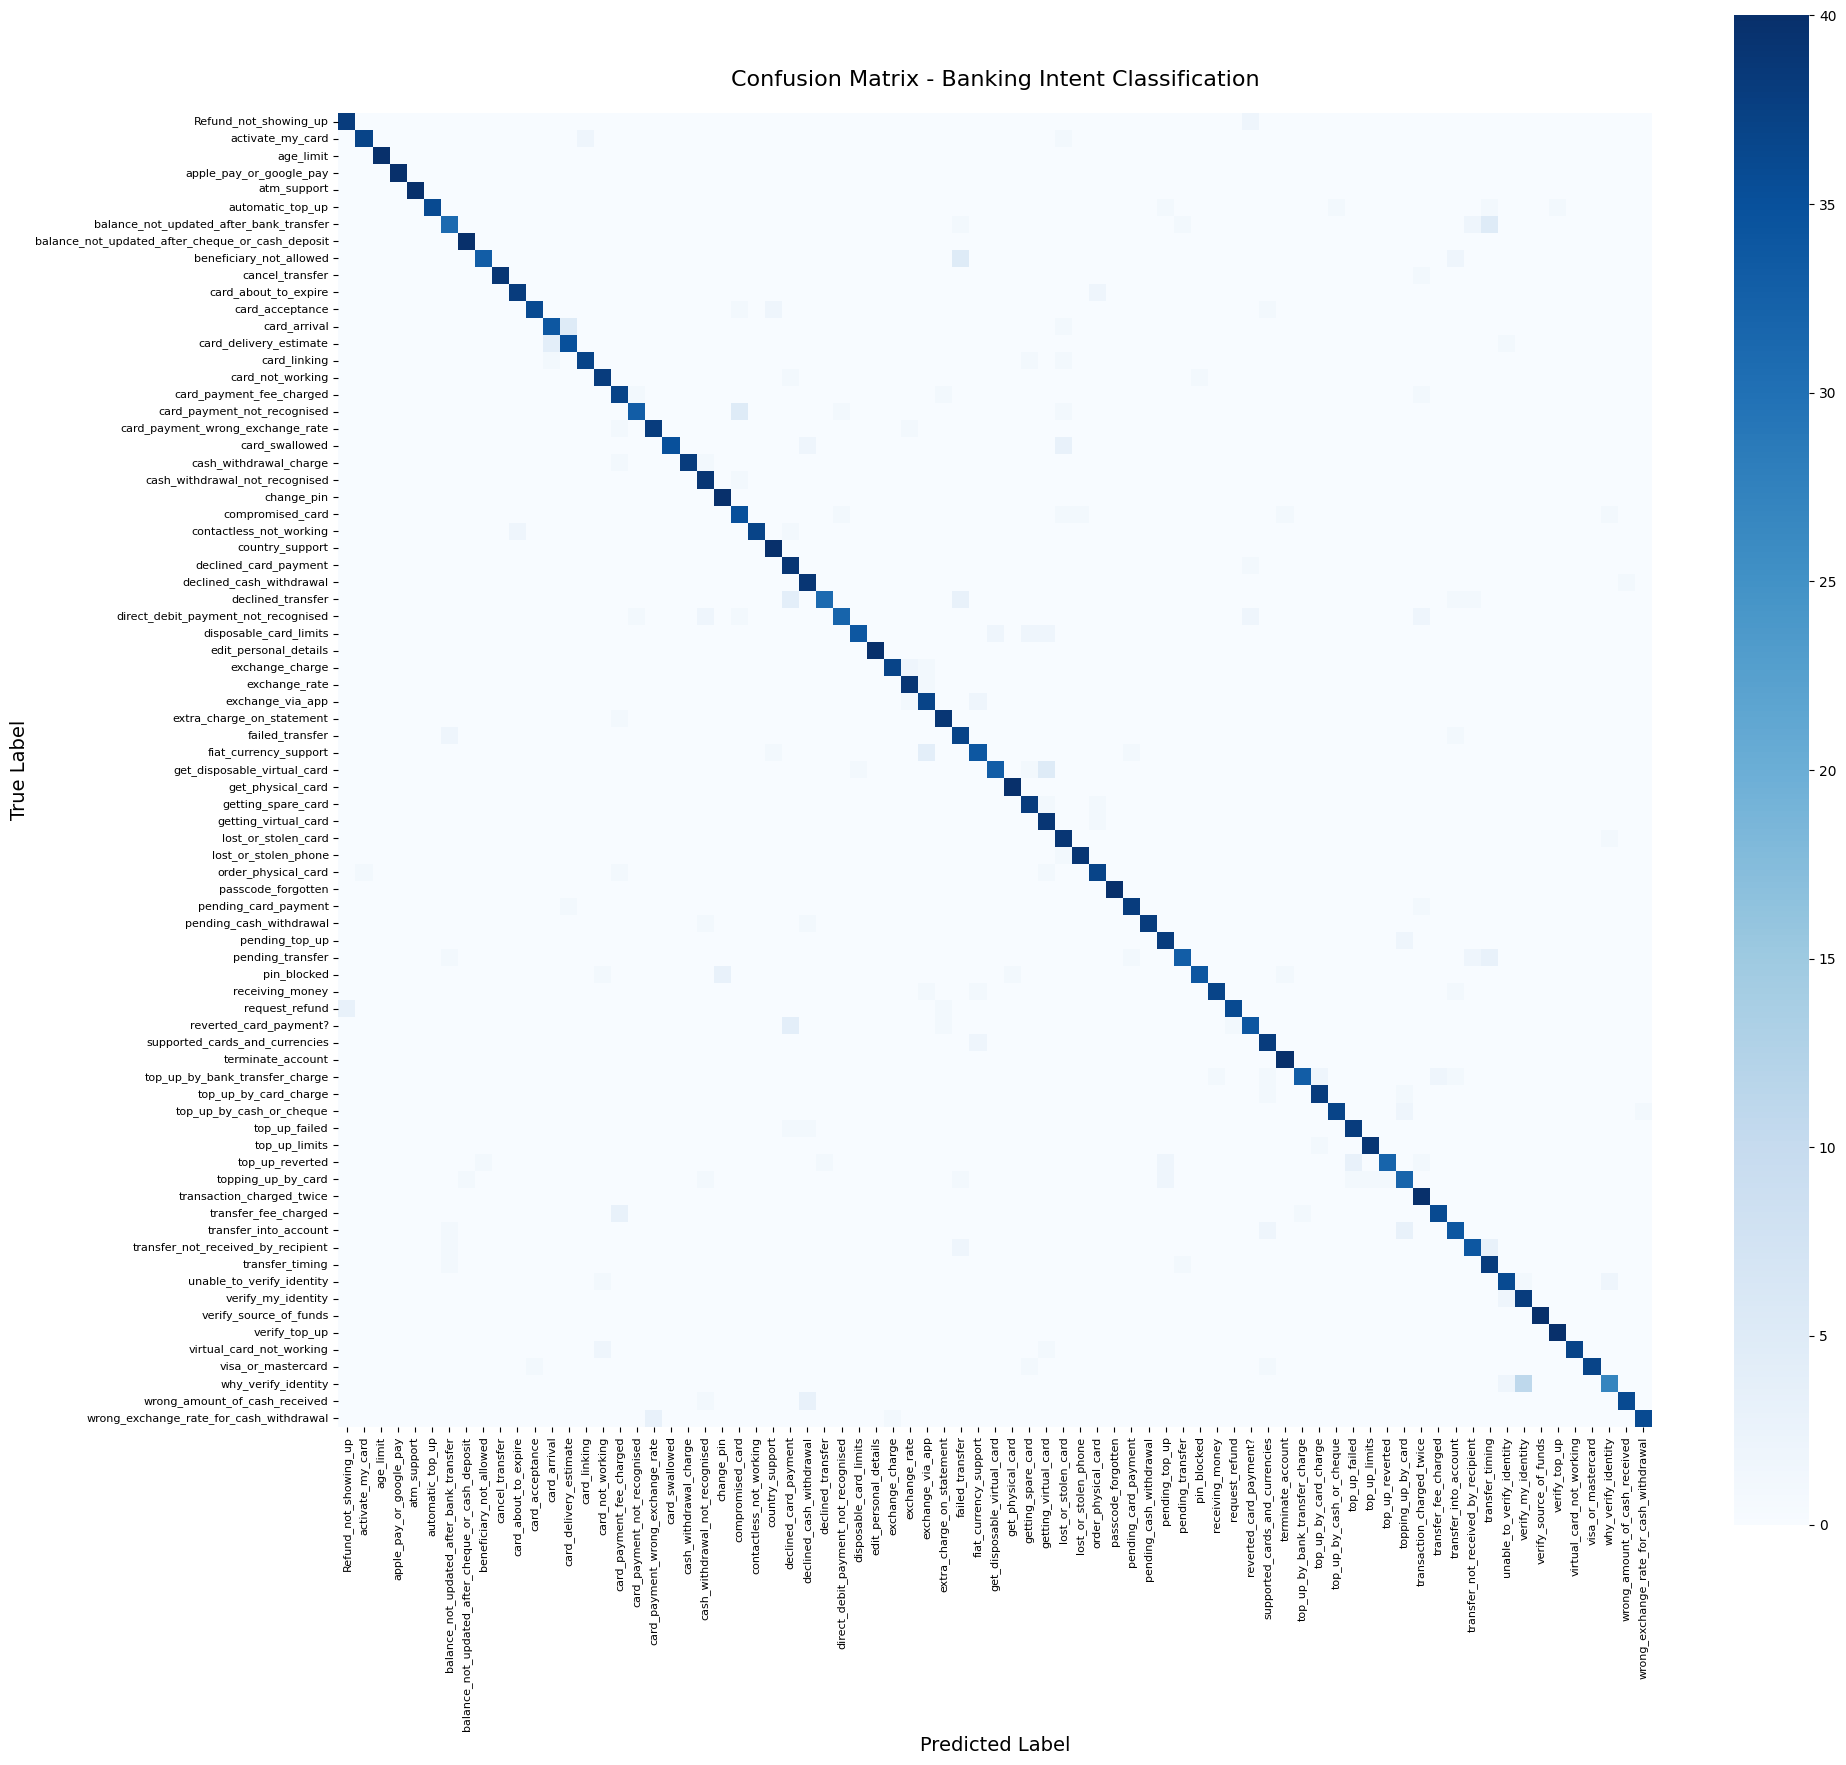


Diagonal sum (correct predictions): 2831
Total predictions: 3080
Accuracy from confusion matrix: 0.9192


In [28]:
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=True, square=True)
plt.title('Confusion Matrix - Banking Intent Classification', fontsize=16, pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(np.arange(num_labels) + 0.5, label_encoder.classes_, rotation=90, fontsize=8)
plt.yticks(np.arange(num_labels) + 0.5, label_encoder.classes_, rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

diagonal_sum = np.trace(cm)
total_sum = np.sum(cm)
print(f"\nDiagonal sum (correct predictions): {diagonal_sum}")
print(f"Total predictions: {total_sum}")
print(f"Accuracy from confusion matrix: {diagonal_sum/total_sum:.4f}")

In [29]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=label_encoder.classes_, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).transpose()

print("Per-class Performance Metrics:")
print(report_df.head(10))

print("\nTop 5 best performing classes (by F1-score):")
class_performance = report_df[:-3].sort_values('f1-score', ascending=False).head(5)
print(class_performance[['precision', 'recall', 'f1-score', 'support']])

print("\nTop 5 worst performing classes (by F1-score):")
worst_performance = report_df[:-3].sort_values('f1-score', ascending=True).head(5)
print(worst_performance[['precision', 'recall', 'f1-score', 'support']])

print("\nOverall Performance Summary:")
print(f"Macro Avg F1: {report_df.loc['macro avg', 'f1-score']:.4f}")
print(f"Weighted Avg F1: {report_df.loc['weighted avg', 'f1-score']:.4f}")

Per-class Performance Metrics:
                                                  precision  recall  f1-score  \
Refund_not_showing_up                              0.926829   0.950  0.938272   
activate_my_card                                   0.973684   0.925  0.948718   
age_limit                                          1.000000   1.000  1.000000   
apple_pay_or_google_pay                            1.000000   1.000  1.000000   
atm_support                                        1.000000   1.000  1.000000   
automatic_top_up                                   1.000000   0.900  0.947368   
balance_not_updated_after_bank_transfer            0.837838   0.775  0.805195   
balance_not_updated_after_cheque_or_cash_deposit   0.975610   1.000  0.987654   
beneficiary_not_allowed                            0.970588   0.825  0.891892   
cancel_transfer                                    1.000000   0.975  0.987342   

                                                  support  
Refund_not_showin

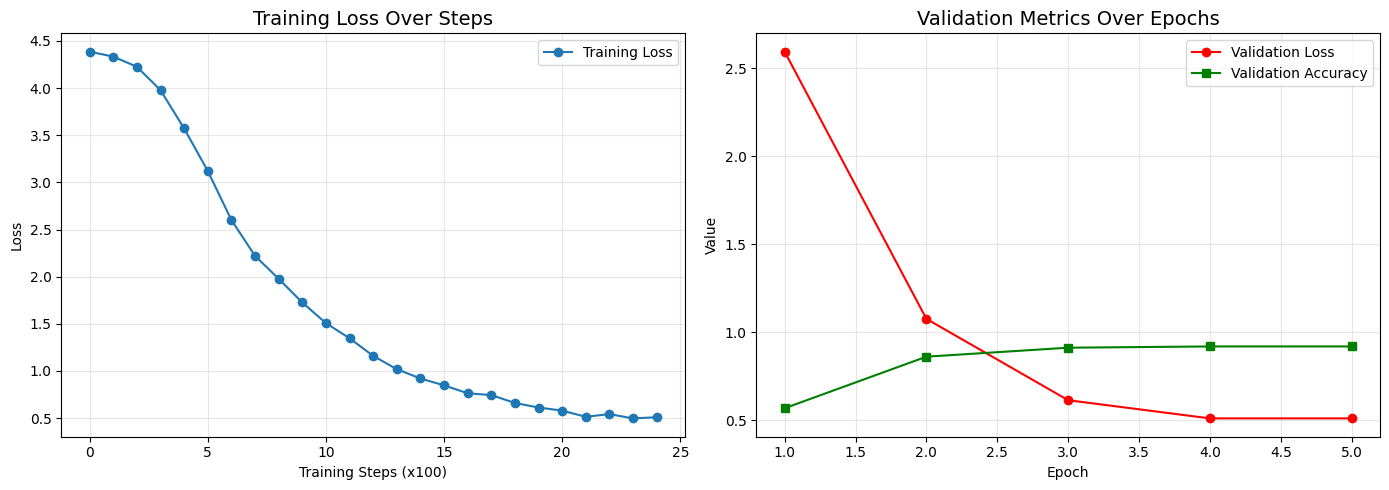

Training steps logged: 25
Evaluation epochs: 5


In [30]:
import json

log_history = trainer.state.log_history

train_loss = [log['loss'] for log in log_history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
eval_accuracy = [log['eval_accuracy'] for log in log_history if 'eval_accuracy' in log]

epochs_range = range(1, len(eval_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss, label='Training Loss', marker='o')
axes[0].set_title('Training Loss Over Steps', fontsize=14)
axes[0].set_xlabel('Training Steps (x100)')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, eval_loss, label='Validation Loss', marker='o', color='red')
axes[1].plot(epochs_range, eval_accuracy, label='Validation Accuracy', marker='s', color='green')
axes[1].set_title('Validation Metrics Over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Training steps logged: {len(train_loss)}")
print(f"Evaluation epochs: {len(eval_loss)}")

In [31]:
import os

output_model_dir = './banking77_bert_model'
os.makedirs(output_model_dir, exist_ok=True)

model.save_pretrained(output_model_dir)
tokenizer.save_pretrained(output_model_dir)

import pickle
with open(f'{output_model_dir}/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

with open(f'{output_model_dir}/label_mappings.pkl', 'wb') as f:
    pickle.dump({'label_to_id': label_to_id, 'id_to_label': id_to_label}, f)

print(f"Model saved to: {output_model_dir}")
print(f"\nSaved files:")
for file in os.listdir(output_model_dir):
    file_path = os.path.join(output_model_dir, file)
    size = os.path.getsize(file_path) / (1024 * 1024)
    print(f"  {file}: {size:.2f} MB")

Model saved to: ./banking77_bert_model

Saved files:
  config.json: 0.00 MB
  model.safetensors: 417.89 MB
  label_mappings.pkl: 0.00 MB
  vocab.txt: 0.22 MB
  label_encoder.pkl: 0.00 MB
  tokenizer_config.json: 0.00 MB
  special_tokens_map.json: 0.00 MB


In [32]:
def predict_intent(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.nn.functional.softmax(logits, dim=-1)
        predicted_class = torch.argmax(probabilities, dim=-1).item()
        confidence = probabilities[0][predicted_class].item()

    return id_to_label[predicted_class], confidence

test_queries = [
    "I lost my credit card, please block it",
    "Why was my payment declined?",
    "How do I activate my new card?",
    "My transfer hasn't arrived yet",
    "What are the fees for ATM withdrawal?"
]

print("Testing model with custom queries:\n")
for query in test_queries:
    intent, confidence = predict_intent(query)
    print(f"Query: {query}")
    print(f"Predicted Intent: {intent}")
    print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    print("-" * 70)

Testing model with custom queries:

Query: I lost my credit card, please block it
Predicted Intent: lost_or_stolen_card
Confidence: 0.3997 (39.97%)
----------------------------------------------------------------------
Query: Why was my payment declined?
Predicted Intent: declined_card_payment
Confidence: 0.7466 (74.66%)
----------------------------------------------------------------------
Query: How do I activate my new card?
Predicted Intent: activate_my_card
Confidence: 0.8761 (87.61%)
----------------------------------------------------------------------
Query: My transfer hasn't arrived yet
Predicted Intent: transfer_not_received_by_recipient
Confidence: 0.3093 (30.93%)
----------------------------------------------------------------------
Query: What are the fees for ATM withdrawal?
Predicted Intent: cash_withdrawal_charge
Confidence: 0.7547 (75.47%)
----------------------------------------------------------------------


In [33]:
import shutil

zip_filename = 'banking77_intent_recognition_project'
shutil.make_archive(zip_filename, 'zip', './banking77_bert_model')

zip_size = os.path.getsize(f'{zip_filename}.zip') / (1024 * 1024)

print(f"Project files zipped successfully!")
print(f"ZIP filename: {zip_filename}.zip")
print(f"ZIP size: {zip_size:.2f} MB")
print(f"\nContents:")
print(f"  - Fine-tuned BERT model (model.safetensors)")
print(f"  - Tokenizer files")
print(f"  - Label encoder and mappings")
print(f"\nReady for download and deployment!")

Project files zipped successfully!
ZIP filename: banking77_intent_recognition_project.zip
ZIP size: 387.11 MB

Contents:
  - Fine-tuned BERT model (model.safetensors)
  - Tokenizer files
  - Label encoder and mappings

Ready for download and deployment!
